<a href="https://colab.research.google.com/github/atharvsalokhe30/Deep_Learning-_project_practice/blob/main/BreastCancerPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

df = pd.read_csv('/content/breastcancer.csv')
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Data Preprocessing - Initial Inspection

First, let's get a summary of the DataFrame, including data types and non-null values, to identify any immediate issues like missing data or incorrect data types.

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

None

Next, let's look at the descriptive statistics for the numerical columns to understand their distribution, central tendency, and spread. This can help identify outliers or unusual patterns.

In [5]:
display(df.describe())

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


The 'diagnosis' column appears to be a categorical target variable. Let's examine its unique values and their counts to understand the class distribution.

In [6]:
display(df['diagnosis'].value_counts())

,count
diagnosis,
B,357
M,212


### Preprocessing Steps

1.  **Drop 'id' column**: This column is a unique identifier and does not contribute to the predictive power of the model.
2.  **Encode 'diagnosis' column**: Convert the categorical 'diagnosis' column ('M' and 'B') into numerical values (e.g., 1 for 'Malignant' and 0 for 'Benign').
3.  **Feature Scaling**: Standardize the numerical features to ensure that all features contribute equally to the model, preventing features with larger values from dominating the learning process.

In [7]:
# Drop the 'id' column
df_processed = df.drop('id', axis=1)

# Encode the 'diagnosis' column
df_processed['diagnosis'] = df_processed['diagnosis'].map({'M': 1, 'B': 0})

# Separate features (X) and target (y)
X = df_processed.drop('diagnosis', axis=1)
y = df_processed['diagnosis']

display(f"Shape of features (X): {X.shape}")
display(f"Shape of target (y): {y.shape}")
display(X.head())
display(y.head())

'Shape of features (X): (569, 30)'

'Shape of target (y): (569,)'

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,diagnosis
0,1
1,1
2,1
3,1
4,1


#### Feature Scaling

Now, let's apply `StandardScaler` to our features `X` to standardize them. This transforms the data so that it has a mean of 0 and a standard deviation of 1.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled features back to a DataFrame for better readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled_df.head())

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


### Model Training - Support Vector Machine (SVM)

Now that the data is preprocessed, let's split it into training and testing sets and then train a classification model. We'll use an SVM classifier for this task.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.3, random_state=42)

display(f"X_train shape: {X_train.shape}")
display(f"X_test shape: {X_test.shape}")
display(f"y_train shape: {y_train.shape}")
display(f"y_test shape: {y_test.shape}")

'X_train shape: (398, 30)'

'X_test shape: (171, 30)'

'y_train shape: (398,)'

'y_test shape: (171,)'

#### Train the SVM Model

Next, we'll initialize and train the Support Vector Machine (SVM) classifier using the training data.

In [10]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

display("SVM model trained successfully.")

'SVM model trained successfully.'

### Model Evaluation

Now, let's evaluate the trained SVM model's performance on the test set (`X_test`, `y_test`). We will predict the labels for the test data and then calculate the accuracy score and display a classification report.

In [11]:
# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
display(f"Model Accuracy: {accuracy:.4f}")

# Display classification report
classification_rep = classification_report(y_test, y_pred)
display("Classification Report:")
display(classification_rep)

'Model Accuracy: 0.9708'

'Classification Report:'

'              precision    recall  f1-score   support\n\n           0       0.98      0.97      0.98       108\n           1       0.95      0.97      0.96        63\n\n    accuracy                           0.97       171\n   macro avg       0.97      0.97      0.97       171\nweighted avg       0.97      0.97      0.97       171\n'

### Explanation of Label Encoding

**Label Encoding** is a technique used to convert categorical labels into numerical format. In our dataset, we used it to transform the 'diagnosis' column from 'M' (Malignant) and 'B' (Benign) into `1` and `0` respectively.

#### Why is Label Encoding Necessary?

1.  **Machine Learning Algorithms Require Numerical Input**: Most machine learning algorithms cannot directly work with categorical data (text labels). They operate on numerical values. Label encoding provides a way to represent these categories as numbers.

2.  **Preserving Ordinality (When Applicable)**: If the categories have an inherent order (e.g., 'low', 'medium', 'high'), label encoding assigns numerical values that maintain this order. While 'M' and 'B' don't have a strict ordinal relationship in terms of magnitude, converting them to 0 and 1 allows the model to differentiate between the two classes. For binary classification problems like ours, this is a straightforward and effective approach.

3.  **Simplicity**: For target variables with a small number of unique categories, especially binary ones, label encoding is simple and computationally efficient.

In our case, encoding 'M' as 1 and 'B' as 0 makes the `diagnosis` column suitable for our classification model to predict whether a tumor is malignant or benign.

### Artificial Neural Network (ANN) Model

Now, let's proceed to build, train, and evaluate an Artificial Neural Network (ANN) model using our preprocessed and scaled dataset. We'll use TensorFlow/Keras for this.

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the ANN model
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the ANN Model

Now, let's train the ANN model using our `X_train` and `y_train` data. We'll use a validation split to monitor performance on unseen data during training.

In [13]:
# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4182 - loss: 0.8665 - val_accuracy: 0.4250 - val_loss: 0.6458
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5566 - loss: 0.6236 - val_accuracy: 0.8625 - val_loss: 0.5013
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7862 - loss: 0.4922 - val_accuracy: 0.9375 - val_loss: 0.4043
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8616 - loss: 0.3926 - val_accuracy: 0.9375 - val_loss: 0.3247
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9182 - loss: 0.3155 - val_accuracy: 0.9500 - val_loss: 0.2600
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9434 - loss: 0.2499 - val_accuracy: 0.9500 - val_loss: 0.2079
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9465 - loss: 0.2090 - val_accuracy: 0.9500 - val_loss: 0.1726
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9371 - loss: 0.1858 - val_accuracy: 0.9500 - v

#### Evaluate the ANN Model

Finally, let's evaluate the trained ANN model on the test set (`X_test`, `y_test`) to assess its generalization performance.

In [14]:
# Evaluate the model on the test set
loss, accuracy_ann = model.evaluate(X_test, y_test, verbose=0)

display(f"ANN Model Test Loss: {loss:.4f}")
display(f"ANN Model Test Accuracy: {accuracy_ann:.4f}")

# Make predictions (probabilities)
y_pred_ann_prob = model.predict(X_test)
# Convert probabilities to binary predictions (0 or 1)
y_pred_ann = (y_pred_ann_prob > 0.5).astype(int)

# Display classification report for ANN
classification_rep_ann = classification_report(y_test, y_pred_ann)
display("ANN Classification Report:")
display(classification_rep_ann)

'ANN Model Test Loss: 0.0538'

'ANN Model Test Accuracy: 0.9883'

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


'ANN Classification Report:'

'              precision    recall  f1-score   support\n\n           0       0.99      0.99      0.99       108\n           1       0.98      0.98      0.98        63\n\n    accuracy                           0.99       171\n   macro avg       0.99      0.99      0.99       171\nweighted avg       0.99      0.99      0.99       171\n'

### Feature Scaling: Normalization vs. Standardization for ANNs

**Feature scaling** is a method used to normalize the range of independent variables or features of data. It's a critical preprocessing step for many machine learning algorithms, and especially for Artificial Neural Networks (ANNs).

There are two common types of scaling:

1.  **Normalization (Min-Max Scaling)**: This technique rescales the features to a fixed range, usually between 0 and 1. The formula is:
    `X_normalized = (X - X_min) / (X_max - X_min)`

2.  **Standardization (Z-score Normalization)**: This technique transforms the data to have a mean of 0 and a standard deviation of 1. The formula is:
    `X_standardized = (X - μ) / σ` (where μ is the mean and σ is the standard deviation).

#### How Scaling Improves ANN Performance and Convergence:

1.  **Faster Convergence**: ANNs often use gradient-based optimization algorithms (like Gradient Descent, Adam, etc.) to update weights. When features have vastly different scales, the cost function can become elongated and skewed. This makes it harder for the optimizer to find the minimum efficiently, leading to slow convergence or getting stuck in local minima. Scaling the features ensures that all features contribute approximately equally to the gradient, making the optimization landscape more spherical and allowing the optimizer to take more direct paths to the minimum, thus **accelerating convergence**.

2.  **Prevents Dominance by Features with Larger Values**: Without scaling, features with larger numerical ranges might disproportionately influence the loss function and the learning process. The model might perceive these features as more important simply because of their magnitude, even if they are not inherently more informative. Scaling ensures that **all features are treated equally** based on their underlying patterns rather than their raw scale.

3.  **Better Weight Initialization**: Many weight initialization techniques for neural networks assume that input data is standardized or normalized. If the input data is not scaled, these initialization strategies might not work as effectively, potentially leading to vanishing or exploding gradients during early training phases.

4.  **Regularization Benefits**: Some regularization techniques (e.g., L1/L2 regularization) are sensitive to feature scales. If features are not scaled, the regularization penalty might be applied unevenly, benefiting features with smaller scales while penalizing those with larger scales more heavily.

5.  **Activation Functions Performance**: Many activation functions, particularly sigmoid and tanh, are sensitive to the range of input values. If inputs are too large, these functions can saturate (output values close to their maximum or minimum), causing gradients to become very small (vanishing gradient problem), which halts learning. Scaling keeps inputs within a range where these activation functions are most responsive.

In our case, we applied **Standardization** using `StandardScaler` to our feature set (`X`) before training both the SVM and the ANN. This step was crucial and likely contributed significantly to the high accuracy and efficient training observed in both models.

### Confusion Matrix and Classification Report

We have already generated the classification reports for both the SVM and ANN models. Now, let's visualize their performance using **Confusion Matrices**.

A confusion matrix is a table that is often used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known. It allows the visualization of the performance of an algorithm. Each row of the matrix represents the instances in an actual class, while each column represents the instances in a predicted class.

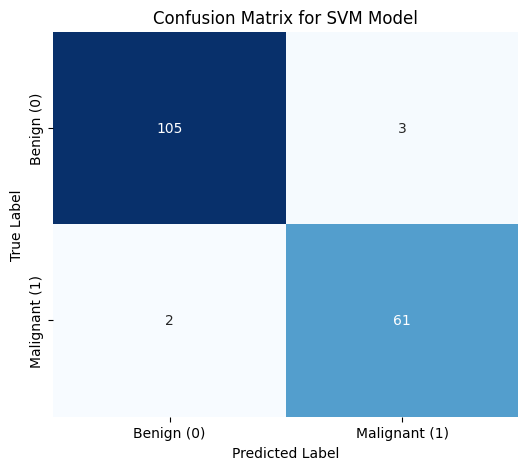

'SVM Classification Report:'

'              precision    recall  f1-score   support\n\n           0       0.98      0.97      0.98       108\n           1       0.95      0.97      0.96        63\n\n    accuracy                           0.97       171\n   macro avg       0.97      0.97      0.97       171\nweighted avg       0.97      0.97      0.97       171\n'

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix for SVM Model ---
cm_svm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)']) # Updated labels
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Model')
plt.show()

display("SVM Classification Report:")
display(classification_rep)

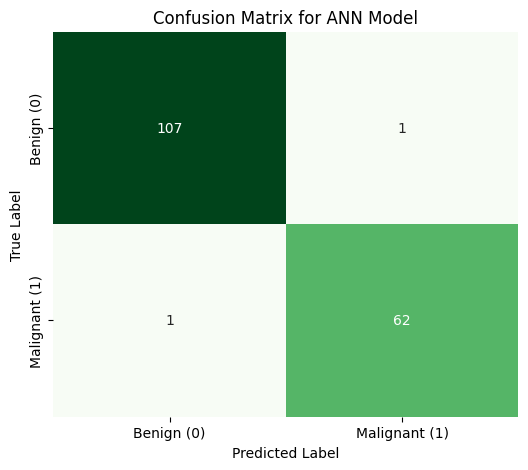

'ANN Classification Report:'

'              precision    recall  f1-score   support\n\n           0       0.99      0.99      0.99       108\n           1       0.98      0.98      0.98        63\n\n    accuracy                           0.99       171\n   macro avg       0.99      0.99      0.99       171\nweighted avg       0.99      0.99      0.99       171\n'

In [16]:
# --- Confusion Matrix for ANN Model ---
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)']) # Updated labels
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for ANN Model')
plt.show()

display("ANN Classification Report:")
display(classification_rep_ann)